# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-05-17 15:06:22.872537: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 15:06:22.884894: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-17 15:06:23.086040: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-17 15:06:23.086187: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-17 15:06:23.086600: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

Python executable: /home/brookewd/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    X_train = np.loadtxt(f"{root_dir}/train/X_train.txt", dtype=np.float32) - 1
    y_train = (np.loadtxt(f"{root_dir}/train/y_train.txt", dtype = np.int32)) - 1
    X_test = np.loadtxt(f"{root_dir}/test/X_test.txt", dtype=np.float32) - 1
    y_test = (np.loadtxt(f"{root_dir}/test/y_test.txt", dtype = np.int32)) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

# <-- Enter your code here <--#

num_features = X_train.shape[1]
num_classes = len(class_names)


## 4. Quick Inspection

In [4]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#


label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

print(dataset_summary)


   Class Index          Class Name  Training Samples
0            0             WALKING              1226
1            1    WALKING_UPSTAIRS              1073
2            2  WALKING_DOWNSTAIRS               986
3            3             SITTING              1286
4            4            STANDING              1374
5            5              LAYING              1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [5]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        #<--- Enter your code here --->#,
        layers.Dense(256, activation="relu", name="h1"),
        #<--- Enter your code here --->#,
        layers.Dense(128, activation="relu", name="h2"),
        #<--- Enter your code here --->#,
        layers.Dense(64, activation="relu", name="h3"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model
    
baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


2026-05-17 15:06:29.752957: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-17 15:06:29.753629: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 h1 (Dense)                  (None, 256)               143872    
                                                                 
 h2 (Dense)                  (None, 128)               32896     
                                                                 
 h3 (Dense)                  (None, 64)                8256      
                                                                 
 dense (Dense)               (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#

history = baseline_model.fit(
    x=X_train,
    y=y_train,
    batch_size=64,
    epochs=40,
    callbacks=callbacks,
    validation_split=0.2,
)


Epoch 1/40
92/92 [==============================] - 2s 11ms/step - loss: 0.8843 - accuracy: 0.6205 - val_loss: 0.4543 - val_accuracy: 0.8464
Epoch 2/40
92/92 [==============================] - 1s 7ms/step - loss: 0.4334 - accuracy: 0.8298 - val_loss: 0.3194 - val_accuracy: 0.8518
Epoch 3/40
92/92 [==============================] - 1s 9ms/step - loss: 0.3205 - accuracy: 0.8670 - val_loss: 0.2046 - val_accuracy: 0.9429
Epoch 4/40
92/92 [==============================] - 1s 9ms/step - loss: 0.2672 - accuracy: 0.8859 - val_loss: 0.1718 - val_accuracy: 0.9436
Epoch 5/40
92/92 [==============================] - 1s 9ms/step - loss: 0.2415 - accuracy: 0.8929 - val_loss: 0.1694 - val_accuracy: 0.9259
Epoch 6/40
92/92 [==============================] - 1s 8ms/step - loss: 0.2352 - accuracy: 0.8983 - val_loss: 0.1468 - val_accuracy: 0.9361
Epoch 7/40
92/92 [==============================] - 1s 8ms/step - loss: 0.2522 - accuracy: 0.8915 - val_loss: 0.1676 - val_accuracy: 0.9239
Epoch 8/40
92/92 [=

### Training Curves

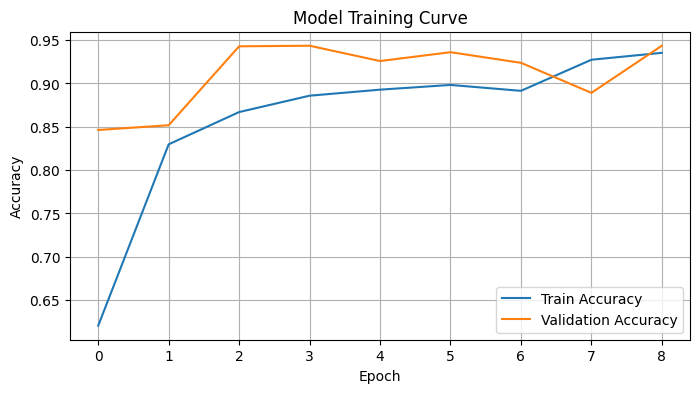

In [7]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()




## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 2ms/step
Test Accuracy: 0.9128
                    precision    recall  f1-score   support

           WALKING       0.94      0.96      0.95       496
  WALKING_UPSTAIRS       0.92      0.95      0.93       471
WALKING_DOWNSTAIRS       0.93      0.88      0.90       420
           SITTING       0.89      0.76      0.82       491
          STANDING       0.82      0.92      0.86       532
            LAYING       0.99      1.00      1.00       537

          accuracy                           0.91      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947



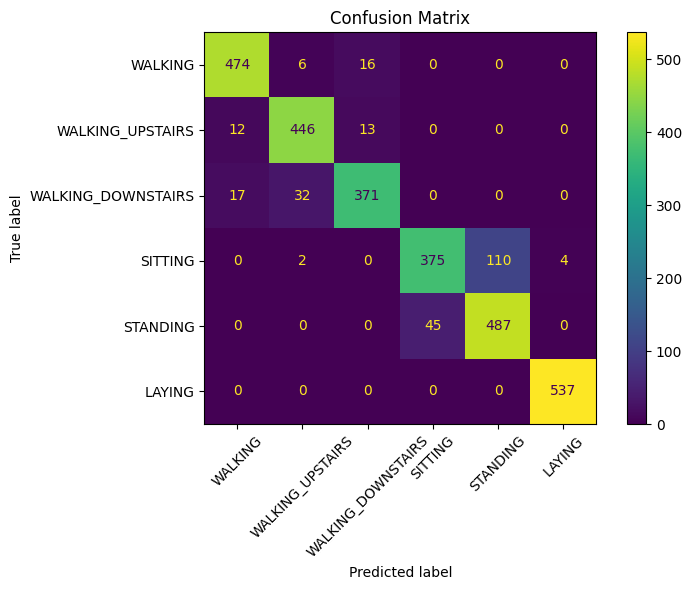

In [8]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#

y_prob = baseline_model.predict(X_test)

# 2. Convert them to class predictions using argmax
y_pred = np.argmax(y_prob, axis=1)

# 3. Compute test accuracy
test_accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# 4. Print the classification report
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [9]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_details["dtype"] == np.int8:
           x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        elif input_details["dtype"] == np.uint8:
            x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        # <-- Enter your code here <--#

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale      

        # <-- Enter your code here <--#

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()
    # <-- Enter your code here <--#
    raise NotImplementedError("Complete the FP32 conversion helper.")


## 8. Convert the Baseline Model to TensorFlow Lite

In [10]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# <-- Enter your code here <--#

m_fp32 = convert_to_tflite_fp32(baseline_model)
path = "fp32.tflite"
with open(path, "wb") as f:
    f.write(m_fp32)
size_kb = os.path.getsize(path) / 1024 

acc, _ = evaluate_tflite_model(m_fp32, X_test, y_test)

summary = pd.DataFrame({
    "Model":    ["fp32lite"],
    "Size(KB)": [size_kb],
    "Accuracy":  [acc]
})

print(summary)


INFO:tensorflow:Assets written to: /tmp/tmp0t4al6_i/assets


INFO:tensorflow:Assets written to: /tmp/tmp0t4al6_i/assets


      Model    Size(KB)  Accuracy
0  fp32lite  726.652344  0.912793


2026-05-17 15:06:45.355360: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-17 15:06:45.355442: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-17 15:06:45.356078: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp0t4al6_i
2026-05-17 15:06:45.357675: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-17 15:06:45.357696: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp0t4al6_i
2026-05-17 15:06:45.383077: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-05-17 15:06:45.384844: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-17 15:06:45.464596: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp0t4al6_i
2026-05

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [11]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#
steps_per_epoch = int(len(X_train) * 0.8) // batch_size

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}



# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#

pruned_model = prune_low_magnitude(
    build_baseline_model(X_train.shape[1], num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#

pruned_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks
)


Epoch 1/12
92/92 [==============================] - 4s 12ms/step - loss: 0.9186 - accuracy: 0.6186 - val_loss: 0.5122 - val_accuracy: 0.8185
Epoch 2/12
92/92 [==============================] - 1s 8ms/step - loss: 0.4829 - accuracy: 0.8012 - val_loss: 0.4079 - val_accuracy: 0.7927
Epoch 3/12
92/92 [==============================] - 1s 9ms/step - loss: 0.3807 - accuracy: 0.8453 - val_loss: 0.2581 - val_accuracy: 0.9245
Epoch 4/12
92/92 [==============================] - 1s 11ms/step - loss: 0.2971 - accuracy: 0.8798 - val_loss: 0.2061 - val_accuracy: 0.9388
Epoch 5/12
92/92 [==============================] - 1s 11ms/step - loss: 0.3197 - accuracy: 0.8733 - val_loss: 0.2188 - val_accuracy: 0.9334
Epoch 6/12
92/92 [==============================] - 1s 12ms/step - loss: 0.3163 - accuracy: 0.8777 - val_loss: 0.2368 - val_accuracy: 0.9279
Epoch 7/12
92/92 [==============================] - 1s 12ms/step - loss: 0.4256 - accuracy: 0.8609 - val_loss: 0.2374 - val_accuracy: 0.9341


## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [12]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
m_pw = convert_to_tflite_fp32(pruned_model)
path_wrapped = "pruned_wrapped.tflite"
with open(path_wrapped, "wb") as f:
    f.write(m_pw)

# 2. Save the model and evaluate it on X_test.
size_kb_w = os.path.getsize(path_wrapped) / 1024 
acc_w, _ = evaluate_tflite_model(m_pw, X_test, y_test)

summary = pd.DataFrame({
    "Model":    ["pruned wrapped"],
    "Size(KB)": [size_kb_w],
    "Accuracy":  [acc_w]
})

print(summary)

# 3. Strip the pruning wrappers using strip_pruning(...).
stripped_model = strip_pruning(pruned_model)

# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
m_ps = converter.convert()

# 5. Save the stripped sparse model and evaluate it on X_test.
path_sparse = "pruned_sparse.tflite"
with open(path_sparse, "wb") as f:
    f.write(m_ps)
    
acc_s, _ = evaluate_tflite_model(m_ps, X_test, y_test)
size_s = os.path.getsize(path_sparse) / 1024
summary = pd.DataFrame({
    "Model":    ["pruned sparce"],
    "Size(KB)": [size_s],
    "Accuracy":  [acc_s]
})

print(summary)
# <-- Enter your code here <--#


INFO:tensorflow:Assets written to: /tmp/tmpkw7p24cq/assets


INFO:tensorflow:Assets written to: /tmp/tmpkw7p24cq/assets
2026-05-17 15:07:07.103546: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-17 15:07:07.103644: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-17 15:07:07.103879: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpkw7p24cq
2026-05-17 15:07:07.107514: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-17 15:07:07.107565: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpkw7p24cq
2026-05-17 15:07:07.117879: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-17 15:07:07.196041: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpkw7p24cq
2026-05-17 15:07:07.220342: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

            Model  Size(KB)  Accuracy
0  pruned wrapped    1454.0  0.876824
INFO:tensorflow:Assets written to: /tmp/tmp7rk2dfvb/assets


INFO:tensorflow:Assets written to: /tmp/tmp7rk2dfvb/assets


           Model    Size(KB)  Accuracy
0  pruned sparce  421.601562  0.876824


2026-05-17 15:07:10.072863: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-17 15:07:10.072942: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-17 15:07:10.073165: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7rk2dfvb
2026-05-17 15:07:10.073809: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-17 15:07:10.073821: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp7rk2dfvb
2026-05-17 15:07:10.075785: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-17 15:07:10.098578: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp7rk2dfvb
2026-05-17 15:07:10.107281: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 34116 m

## 11. Part I Comparison: Accuracy and Model Size

In [13]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#

models = {
    "baseline model": m_fp32,
    "pruned + masked model": m_pw,
    "sparse model": m_ps
}

accuracies = [acc, acc_w, acc_s]
sizes = [size_kb, size_kb_w, size_s]
comp_dataframe = pd.DataFrame({
    "Model":    list(models.keys()),
    "Size(KB)": sizes,
    "Accuracy": accuracies
})

print(comp_dataframe)


                   Model     Size(KB)  Accuracy
0         baseline model   726.652344  0.912793
1  pruned + masked model  1454.000000  0.876824
2           sparse model   421.601562  0.876824


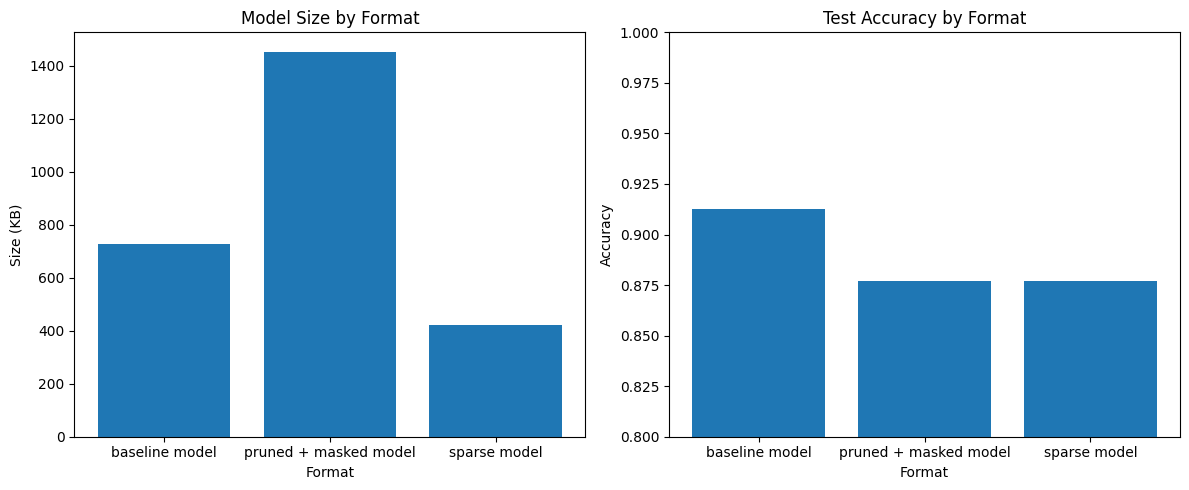

In [14]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Model Size
ax1.bar(comp_dataframe["Model"], comp_dataframe["Size(KB)"])
ax1.set_title("Model Size by Format")
ax1.set_xlabel("Format")
ax1.set_ylabel("Size (KB)")

# Test Accuracy
ax2.bar(comp_dataframe["Model"], comp_dataframe["Accuracy"])
ax2.set_title("Test Accuracy by Format")
ax2.set_xlabel("Format")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.8, 1.0)  

plt.tight_layout()
plt.show()



### Confusion Matrix for the Stripped Sparse Model

                    precision    recall  f1-score   support

           WALKING       0.79      0.97      0.87       496
  WALKING_UPSTAIRS       0.96      0.73      0.83       471
WALKING_DOWNSTAIRS       0.86      0.86      0.86       420
           SITTING       0.87      0.78      0.82       491
          STANDING       0.82      0.91      0.87       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.88      2947
         macro avg       0.88      0.87      0.87      2947
      weighted avg       0.88      0.88      0.88      2947



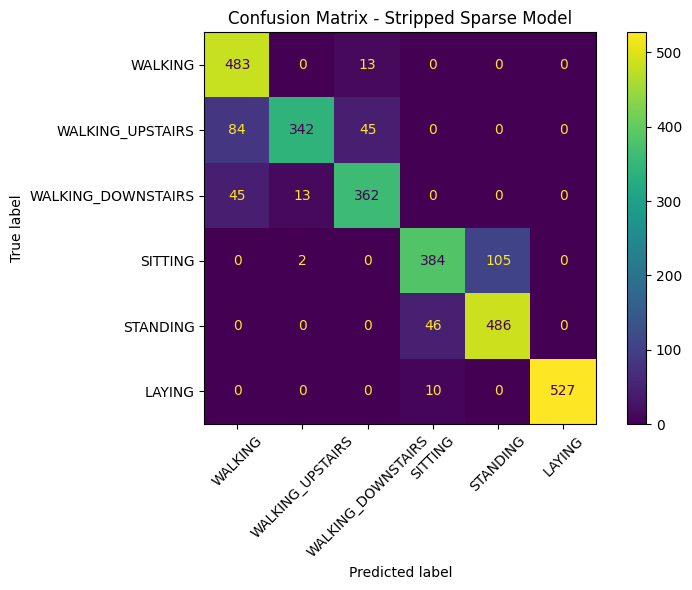

In [15]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#
foo, y_pred_strip = evaluate_tflite_model(m_ps, X_test, y_test)

# Classification report
print(classification_report(y_test, y_pred_strip, target_names=class_names))

# Confusion matrix
cm_strip = confusion_matrix(y_test, y_pred_strip)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_strip, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Stripped Sparse Model")
plt.tight_layout()
plt.show()


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [16]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#

#1
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
m_wrapped_f16 = converter.convert()

#2
path_wf16 = "pruned_wrapped_f16.tflite"
with open(path_wf16, "wb") as f:
    f.write(m_wrapped_f16)
#####
print("Size (pruned + f16):", os.path.getsize(path_wf16), "bytes")
print("Accuracy (pruned + f16):", evaluate_tflite_model(m_wrapped_f16, X_test, y_test)[0])
###


#3
converter_2 = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter_2.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter_2.target_spec.supported_types = [tf.float16]
m_sparce_f16 = converter_2.convert()

#4
path_sf16 = "pruned_sparce_f16.tflite"
with open(path_sf16, "wb") as f:
    f.write(m_sparce_f16)

###
print("Size (sparse + f16):", os.path.getsize(path_sf16), "bytes")
print("Accuracy (sparse + f16):", evaluate_tflite_model(m_sparce_f16, X_test, y_test)[0])
###


INFO:tensorflow:Assets written to: /tmp/tmpx2jl2lda/assets


INFO:tensorflow:Assets written to: /tmp/tmpx2jl2lda/assets
2026-05-17 15:07:18.972946: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-17 15:07:18.973036: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-17 15:07:18.973260: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpx2jl2lda
2026-05-17 15:07:18.976242: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-17 15:07:18.976272: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpx2jl2lda
2026-05-17 15:07:18.984924: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-17 15:07:19.064938: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpx2jl2lda
2026-05-17 15:07:19.097668: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Size (pruned + f16): 749952 bytes
Accuracy (pruned + f16): 0.8771632168306752
INFO:tensorflow:Assets written to: /tmp/tmpjdfdxg8t/assets


INFO:tensorflow:Assets written to: /tmp/tmpjdfdxg8t/assets


Size (sparse + f16): 284436 bytes
Accuracy (sparse + f16): 0.8771632168306752


2026-05-17 15:07:22.012461: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-17 15:07:22.012551: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-17 15:07:22.012792: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpjdfdxg8t
2026-05-17 15:07:22.013620: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-17 15:07:22.013639: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpjdfdxg8t
2026-05-17 15:07:22.015642: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-17 15:07:22.041363: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpjdfdxg8t
2026-05-17 15:07:22.052187: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 39395 m

## 12. Part II Comparison: Accuracy and Model Size

In [17]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#

models = {
    "pruned + masked FP32": m_pw,
    "sparse FP32": m_ps,
    "pruned + masked float16": m_wrapped_f16,
    "sparse float16": m_sparce_f16
}

accuracies = [acc_w, acc_s, evaluate_tflite_model(m_wrapped_f16, X_test, y_test)[0], evaluate_tflite_model(m_sparce_f16, X_test, y_test)[0]]
sizes = [size_kb_w, size_s, os.path.getsize(path_wf16)/1024,  os.path.getsize(path_sf16)/1024]
comparison_dataframe_big = pd.DataFrame({
    "Model":    list(models.keys()),
    "Size(KB)": sizes,
    "Accuracy": accuracies
})

print(comparison_dataframe_big)


                     Model     Size(KB)  Accuracy
0     pruned + masked FP32  1454.000000  0.876824
1              sparse FP32   421.601562  0.876824
2  pruned + masked float16   732.375000  0.877163
3           sparse float16   277.769531  0.877163


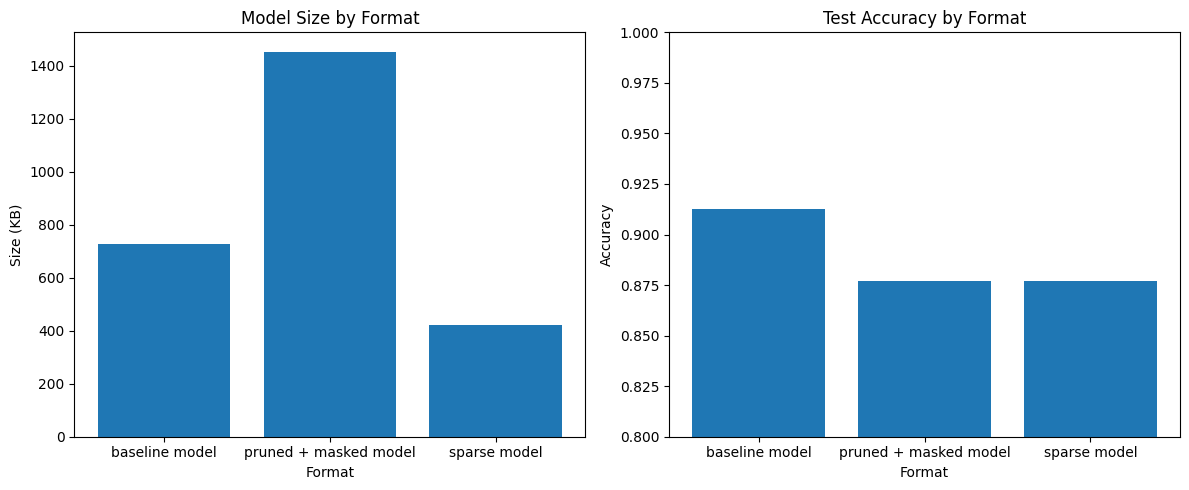

In [18]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Model Size
ax1.bar(comp_dataframe["Model"], comp_dataframe["Size(KB)"])
ax1.set_title("Model Size by Format")
ax1.set_xlabel("Format")
ax1.set_ylabel("Size (KB)")

# Test Accuracy
ax2.bar(comp_dataframe["Model"], comp_dataframe["Accuracy"])
ax2.set_title("Test Accuracy by Format")
ax2.set_xlabel("Format")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.8, 1.0)  

plt.tight_layout()
plt.show()



### Confusion Matrix for the Stripped Sparse + Float16 Model

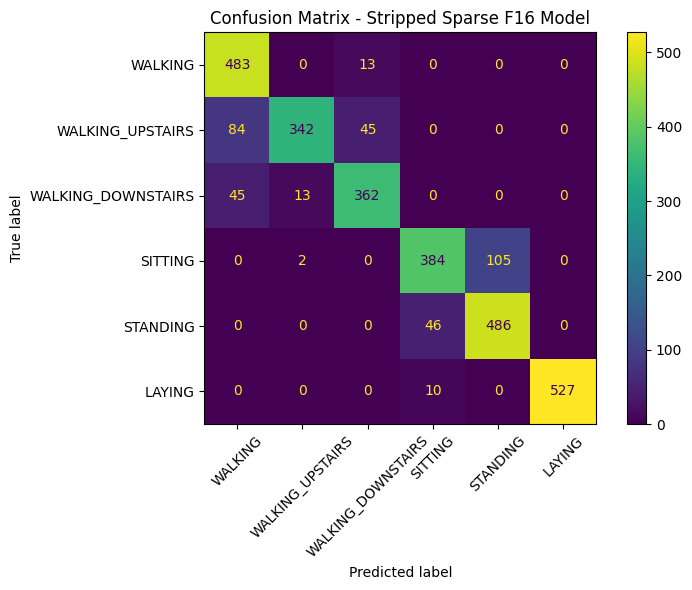

              precision    recall  f1-score   support

           0       0.79      0.97      0.87       496
           1       0.96      0.73      0.83       471
           2       0.86      0.86      0.86       420
           3       0.87      0.78      0.82       491
           4       0.82      0.91      0.87       532
           5       1.00      0.98      0.99       537

    accuracy                           0.88      2947
   macro avg       0.88      0.87      0.87      2947
weighted avg       0.89      0.88      0.88      2947



In [19]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#

_, y_pred = evaluate_tflite_model(m_sparce_f16, X_test, y_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_strip, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Stripped Sparse F16 Model")
plt.tight_layout()
plt.show()


# Classification report
print(classification_report(y_test, y_pred))


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
2. Why does `strip_pruning(...)` matter before export?
3. Which model had the smallest file size in this notebook?
4. Did float16 quantization noticeably change the test accuracy?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
